In [1]:
import numpy as np
import pandas as pd
from tabulate import tabulate
import os, logging
import dask.dataframe as dd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from dask.distributed import Client
from dask.diagnostics import ProgressBar

PARQUET_EXTENSION = '.parquet'

client = Client() #n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 15.87 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62434,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 15.87 GiB
Comm: tcp://127.0.0.1:62464,Total threads: 2
Dashboard: http://127.0.0.1:62465/status,Memory: 3.97 GiB
Nanny: tcp://127.0.0.1:62437,


In [2]:

TRIPS_COLUMNS = [
    "tripduration",
    "starttime",
    "stoptime",
    "startstationid",
    "startstationname",
    "startstationlatitude",
    "startstationlongitude",
    "endstationid",
    "endstationname",
    "endstationlatitude",
    "endstationlongitude",
    "bikeid",
    "usertype",
    "birthyear",
    "gender",
]

ddf_trips = dd.read_parquet('data/bike/pqt/2019/2019.parquet', columns=TRIPS_COLUMNS, engine='pyarrow')

#Change time types to datetime
ddf_trips['starttime'] = ddf_trips['starttime'].astype('datetime64')
ddf_trips['stoptime'] = ddf_trips['stoptime'].astype('datetime64')
ddf_trips['birthyear'] = ddf_trips['birthyear'].astype('int32').persist()

print(ddf_trips)



Dask DataFrame Structure:
               tripduration       starttime        stoptime startstationid startstationname startstationlatitude startstationlongitude endstationid endstationname endstationlatitude endstationlongitude bikeid usertype birthyear gender
npartitions=12                                                                                                                                                                                                                            
                      int64  datetime64[ns]  datetime64[ns]        float64           object              float64               float64      float64         object            float64             float64  int64   object     int32  int64
                        ...             ...             ...            ...              ...                  ...                   ...          ...            ...                ...                 ...    ...      ...       ...    ...
...                     ...       

In [3]:

with ProgressBar():
    print(f'There are {len(ddf_trips)/10**6} million rows')
    print(ddf_trips.head(5))


There are 20.551517 million rows
   tripduration               starttime                stoptime  \
0           320 2019-01-01 00:01:47.401 2019-01-01 00:07:07.581   
1           316 2019-01-01 00:04:43.736 2019-01-01 00:10:00.608   
2           591 2019-01-01 00:06:03.997 2019-01-01 00:15:55.438   
3          2719 2019-01-01 00:07:03.545 2019-01-01 00:52:22.650   
4           303 2019-01-01 00:07:35.945 2019-01-01 00:12:39.502   

   startstationid             startstationname  startstationlatitude  \
0          3160.0  Central Park West & W 76 St             40.778968   
1           519.0        Pershing Square North             40.751873   
2          3171.0      Amsterdam Ave & W 82 St             40.785247   
3           504.0              1 Ave & E 16 St             40.732219   
4           229.0               Great Jones St             40.727434   

   startstationlongitude  endstationid          endstationname  \
0             -73.973747        3283.0  W 89 St & Columbus Ave   

In [4]:
a = ddf_trips.memory_usage_per_partition(deep=True).compute()
#print(f'Dataframe is {round(a/(2**30),2)}GB')
print(round(a/(2**30),2))

0     0.29
1     0.28
2     0.40
3     0.53
4     0.57
5     0.63
6     0.65
7     0.70
8     0.73
9     0.62
10    0.44
11    0.28
dtype: float64


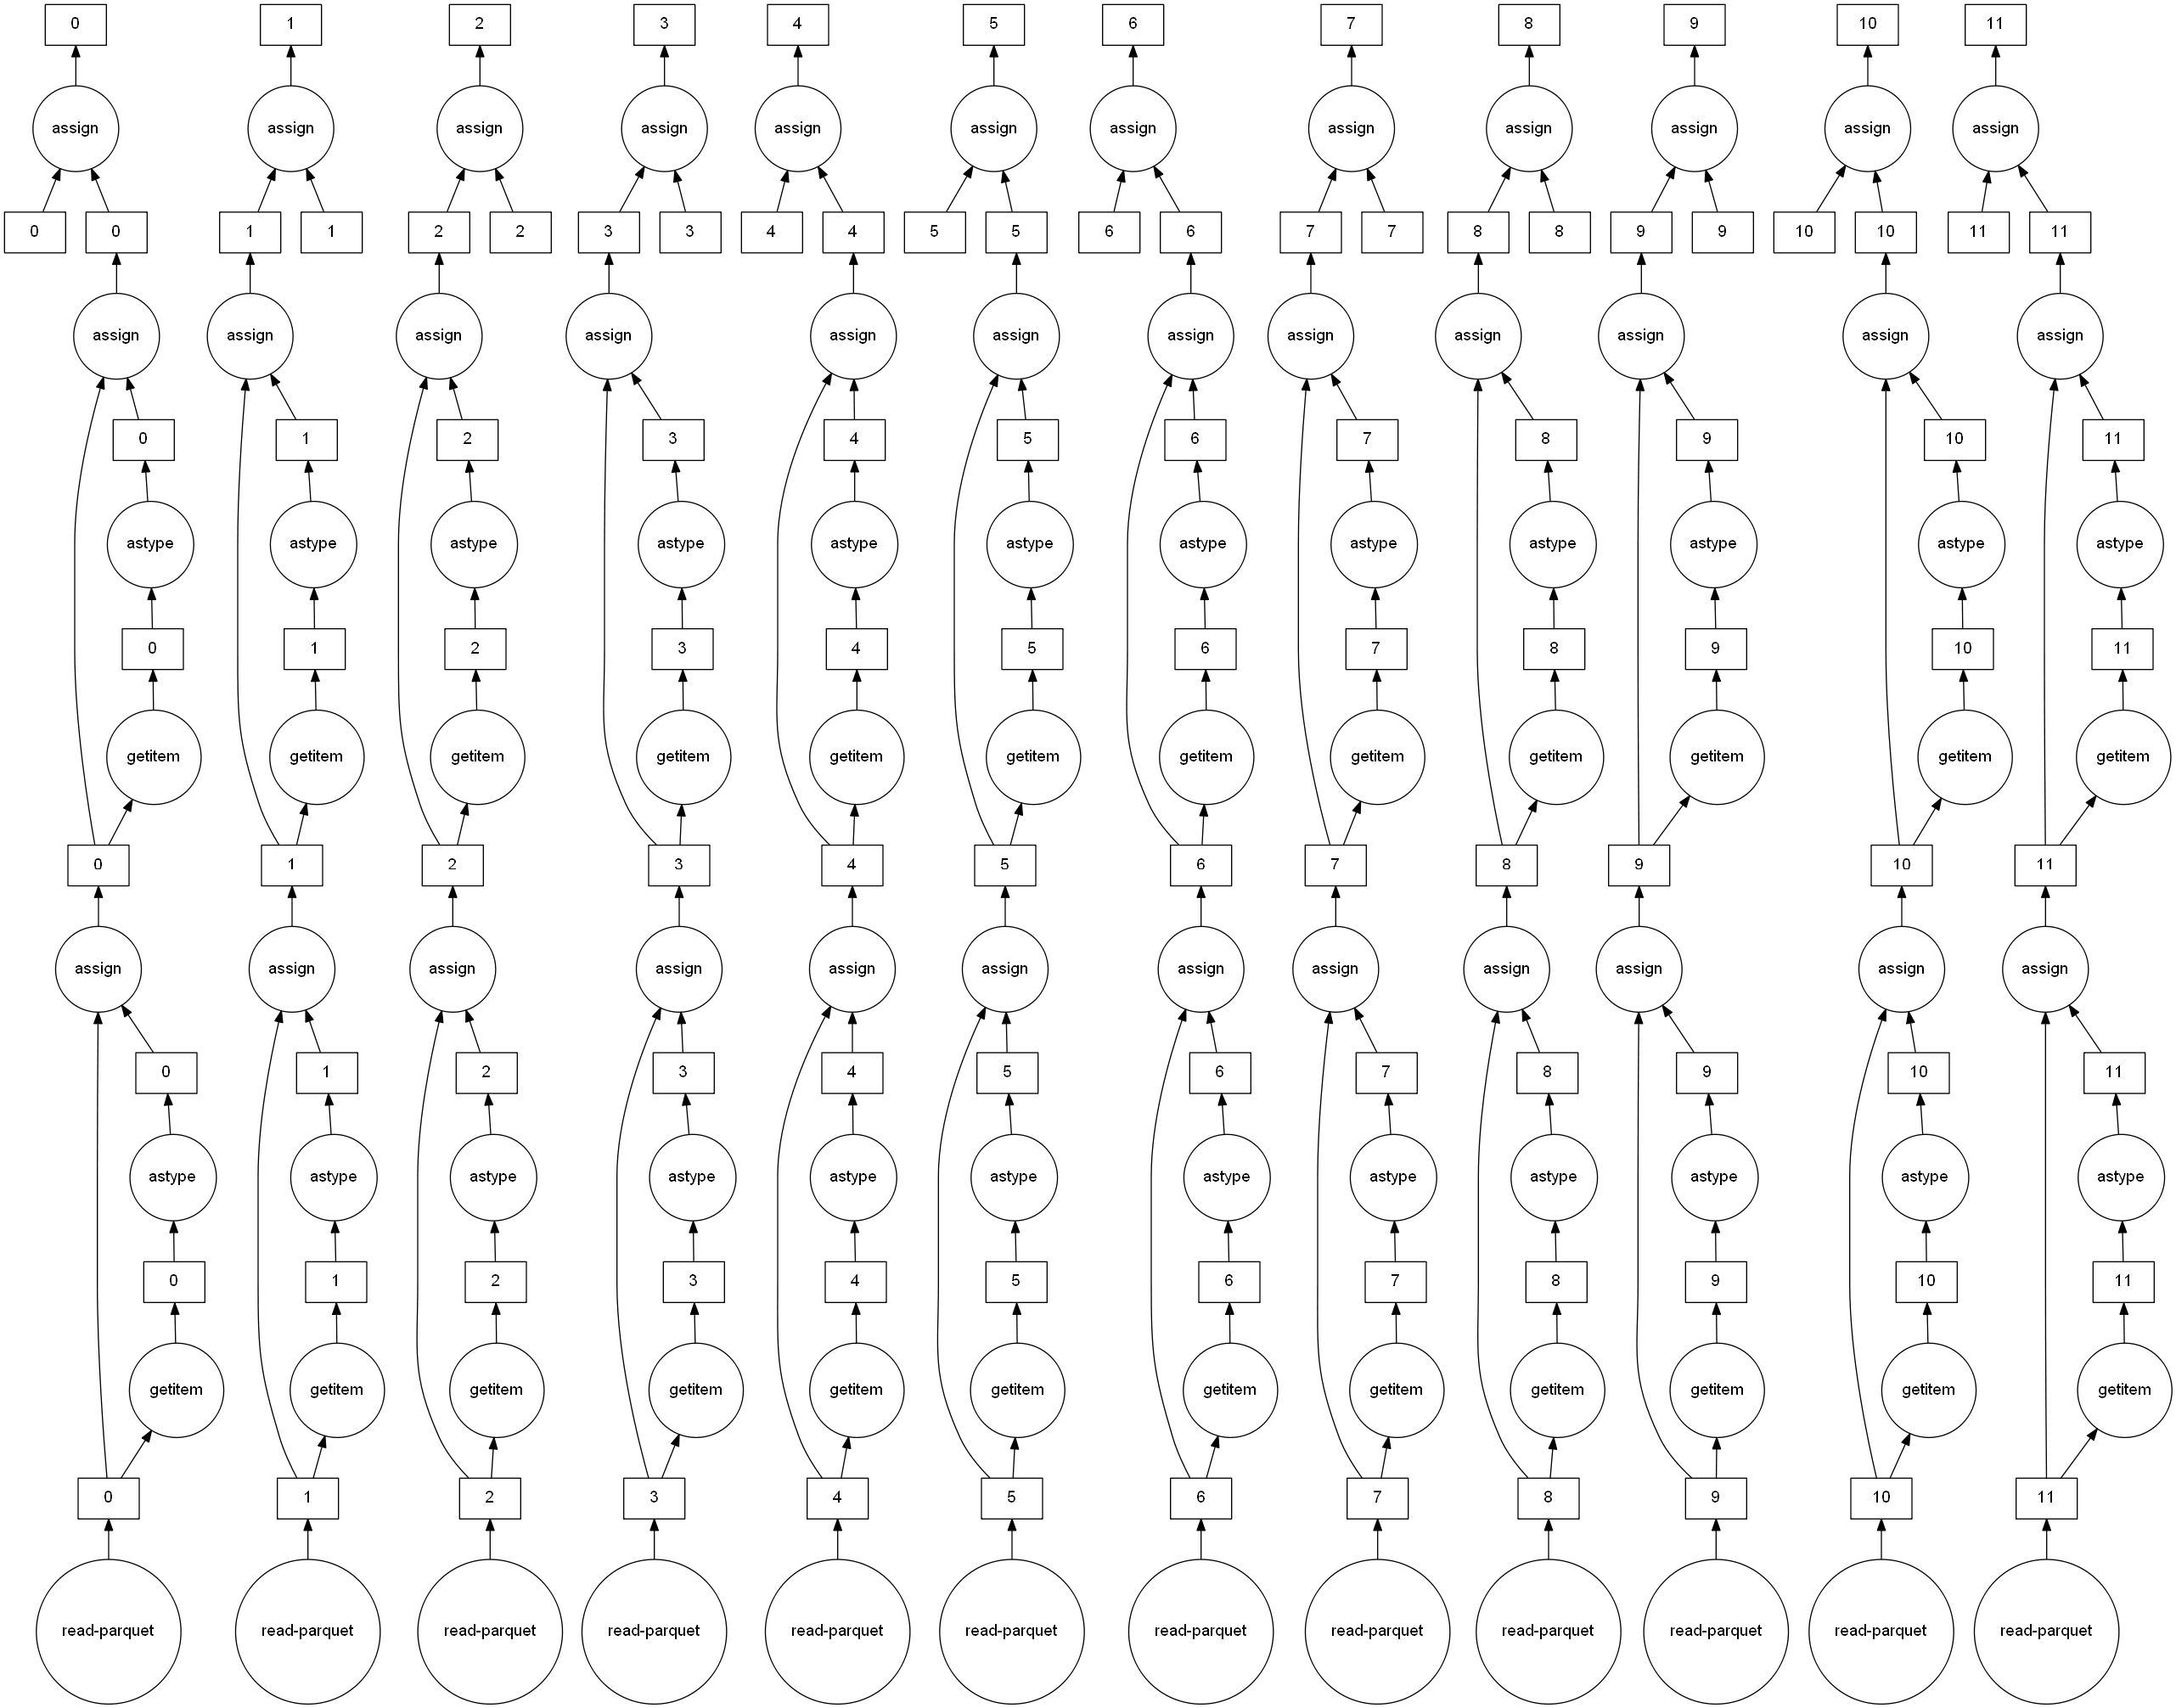

In [5]:
ddf_trips.visualize()

In [6]:
with ProgressBar():
    oldest_person = ddf_trips['birthyear'].min().compute()
    print(oldest_person)

1857


In [7]:
count_non_subs = ddf_trips[ddf_trips['usertype'] != "Subscriber"].shape[0] #.compute()
count_subs = ddf_trips[ddf_trips['usertype'] == "Subscriber"].shape[0] #.compute()
print(count_non_subs, count_subs)

Delayed('int-160d51c2-ab29-4515-aa10-61260971161f') Delayed('int-ba444dbb-c617-4578-8fe7-53a2cee499ba')


In [8]:
import dask

with ProgressBar():
    count_non_subs_result, count_subs_result = dask.compute(count_non_subs, count_subs)
    print(count_non_subs_result, count_subs_result)


2872124 17679393


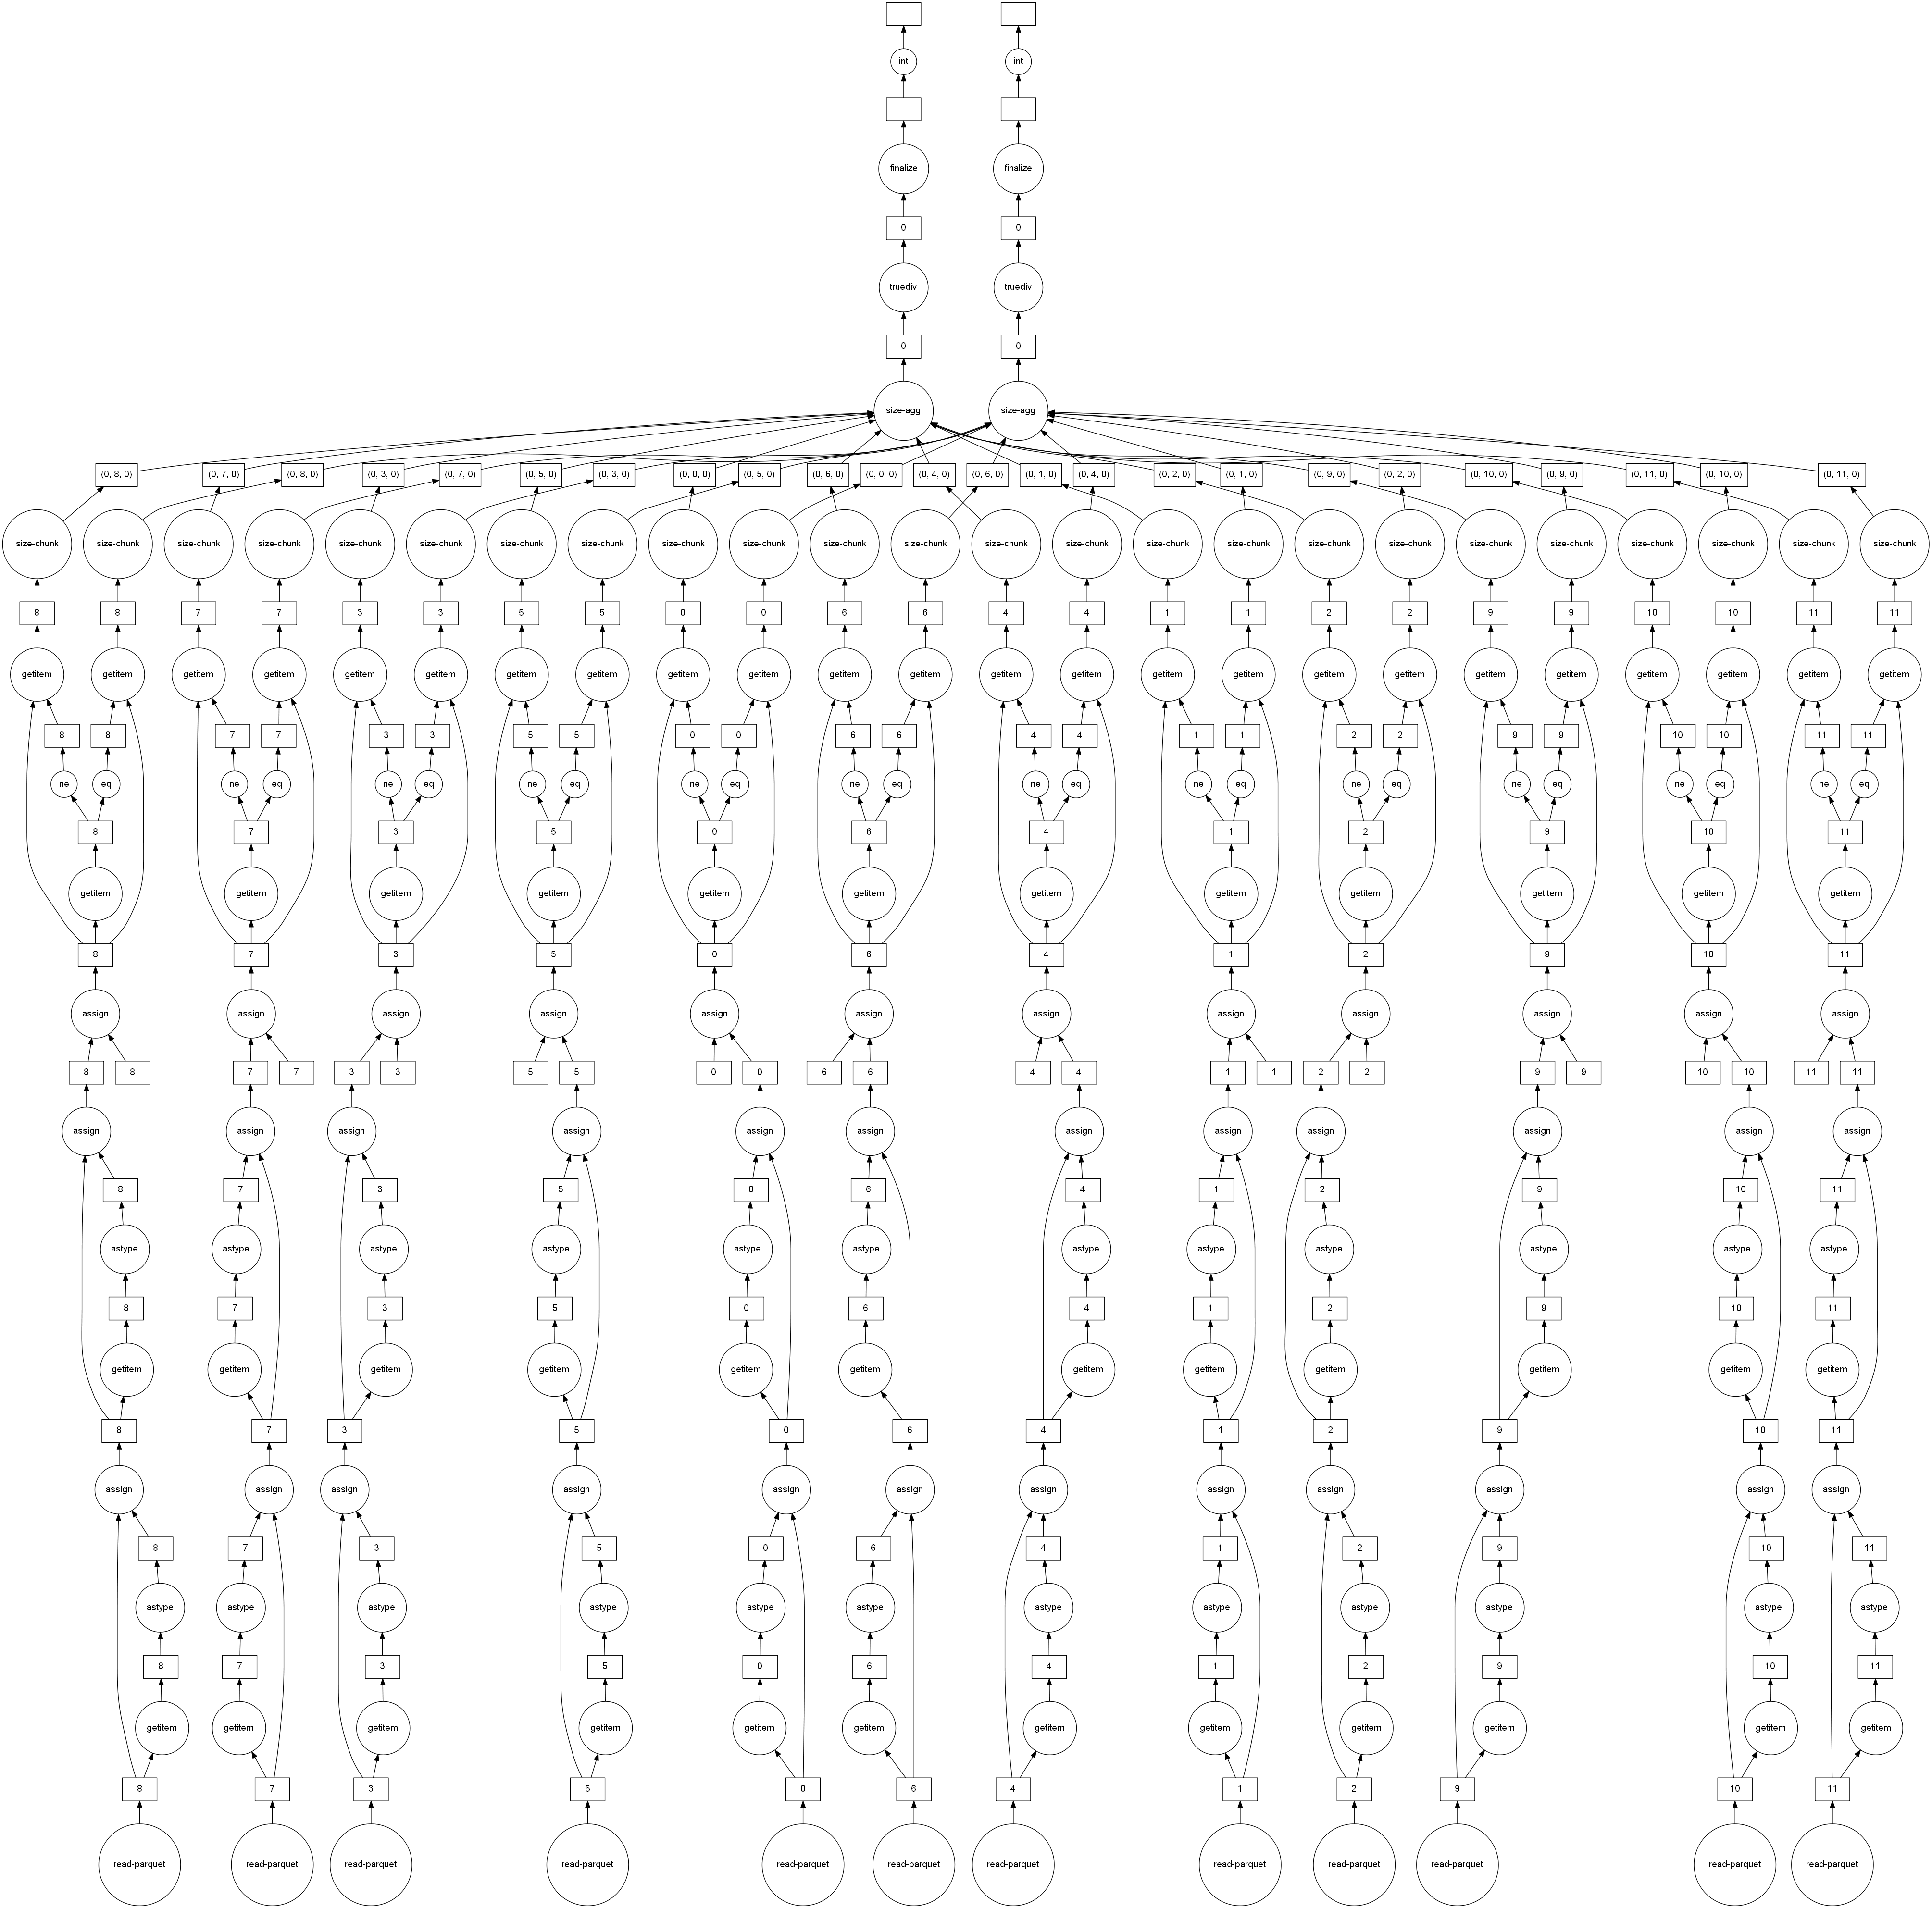

In [9]:
dask.visualize(count_non_subs, count_subs)

In [10]:
# Make new date and one hour col
trips_date_col = ddf_trips['starttime'].dt.date
trips_hour_col = ddf_trips['starttime'].dt.hour
trips_month_col = ddf_trips['starttime'].dt.month
ddf_trips_date = ddf_trips.assign(tripday=trips_date_col)
#ddf_trips_date2 = ddf_trips_date.renam(columns={'tripday':'trip_day'})
ddf_trips_date = ddf_trips_date.assign(tripstarthour=trips_hour_col)
ddf_trips_date = ddf_trips_date.assign(tripsmonth=trips_month_col)

with ProgressBar():
    print(ddf_trips_date.head(3))

   tripduration               starttime                stoptime  \
0           320 2019-01-01 00:01:47.401 2019-01-01 00:07:07.581   
1           316 2019-01-01 00:04:43.736 2019-01-01 00:10:00.608   
2           591 2019-01-01 00:06:03.997 2019-01-01 00:15:55.438   

   startstationid             startstationname  startstationlatitude  \
0          3160.0  Central Park West & W 76 St             40.778968   
1           519.0        Pershing Square North             40.751873   
2          3171.0      Amsterdam Ave & W 82 St             40.785247   

   startstationlongitude  endstationid          endstationname  \
0             -73.973747        3283.0  W 89 St & Columbus Ave   
1             -73.977706         518.0         E 39 St & 2 Ave   
2             -73.976673        3154.0         E 77 St & 3 Ave   

   endstationlatitude  endstationlongitude  bikeid    usertype  birthyear  \
0           40.788221           -73.970416   15839  Subscriber       1971   
1           40.747804  

In [11]:
trips_by_hour = ddf_trips_date.groupby(['tripday', 'tripstarthour'])['tripduration'].count().reset_index()
with ProgressBar():
    print(trips_by_hour.head(5))

      tripday  tripstarthour  tripduration
0  2019-01-01              0           133
1  2019-01-01              1           272
2  2019-01-01              2           283
3  2019-01-01              3           187
4  2019-01-01              4           120


In [12]:
trips_by_month = ddf_trips_date.groupby(['tripsmonth'])['tripduration'].count().reset_index()
with ProgressBar():
    print(trips_by_month.head(3))
    print(type('trips_by_month'))

   tripsmonth  tripduration
0           1        967269
1           2        943735
2           3       1327950
<class 'str'>


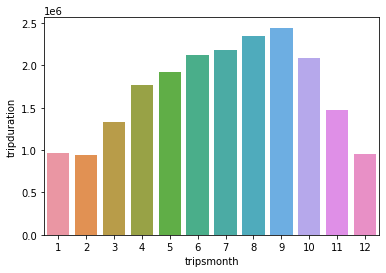

In [13]:
plt.figure()
sns.barplot(x='tripsmonth', y='tripduration', data=trips_by_month.compute())
plt.show()

In [14]:
# Group df to see hourly patterns, can't use same col twice because it gives the same
# name to the series index

trips_by_hour = (ddf_trips.groupby([ddf_trips['starttime'].dt.date,
                                    ddf_trips['starttime'].dt.hour])['tripduration']
                 .count())
print(trips_by_hour.head(3))

starttime   starttime
2019-01-01  0            133
            1            272
            2            283
Name: tripduration, dtype: int64


In [15]:
df_by_hour = trips_by_hour.compute()
df_by_hour.index.names = [None,None]
df_by_hour = df_by_hour.reset_index().rename(columns={"level_0":"startdate", "level1":"starttime", "tripduration":"#trips"})
print(df_by_hour.head(3))

    startdate  level_1  #trips
0  2019-01-01        0     133
1  2019-01-01        1     272
2  2019-01-01        2     283


In [16]:
trips_cats = ddf_trips['usertype'].unique().compute()
trips_usertype_zeros = ddf_trips['usertype'].isna().sum().compute()

print(trips_cats)
print(trips_usertype_zeros)

0    Subscriber
1      Customer
Name: usertype, dtype: object
0


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
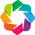

:Histogram   [x]   (Frequency)

In [17]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

freq, edges = np.histogram(ddf_trips['birthyear'], 40)
hv.Histogram((freq,edges))

In [18]:
freq, edges = np.histogram(ddf_trips['tripduration'], 40)
hv.Histogram((freq,edges))

:Histogram   [x]   (Frequency)

In [19]:
day_trips = (ddf_trips.groupby(ddf_trips['starttime'].dt.date)['tripduration']
    .count()
    .reset_index()
    .rename(columns={"starttime": "dayofyear", "tripduration": "counttrips"})
)

print(type(day_trips))
print(day_trips.head(5))

<class 'dask.dataframe.core.DataFrame'>
    dayofyear  counttrips
0  2019-01-01       21962
1  2019-01-02       37797
2  2019-01-03       41676
3  2019-01-04       43922
4  2019-01-05       17432


In [20]:
import hvplot.dask

day_trips.hvplot(x='dayofyear', y='counttrips')

:Curve   [dayofyear]   (counttrips)

In [21]:
#print(day_trips.isna().sum().compute())
# print(len(day_trips))

df = day_trips.compute()
print(type(df))

<class 'pandas.core.frame.DataFrame'>


(365, 2)
Index(['dayofyear', 'counttrips'], dtype='object')


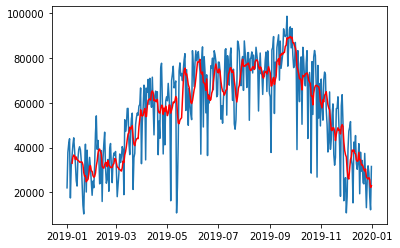

In [22]:
print(df.shape)
print(df.columns)

plt.figure()
plt.plot(df.dayofyear.values, df.counttrips.values)
plt.plot(df.dayofyear.values, df['counttrips'].rolling(7).mean(), color='red')
plt.show()

In [23]:
from holoviews.operation.datashader import datashade

#x_range = (day_trips.iloc[0,'dayofyear'], day_trips.iloc[-1,'dayofyear'])
#y_range = (1.2*day_trips.counttrips.min(),1.2*day_trips.counttrips.max())

points = hv.Points(day_trips, kdims=['dayofyear', 'counttrips'])

curve = hv.Curve((day_trips.dayofyear, day_trips.counttrips), sigma=1)
datashade(curve, cmap=['blue']).opts(width=800)

tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 2 memory: 317 MB fds: -1>>
Traceback (most recent call last):
  File "c:\Users\PatCa\anaconda3\lib\site-packages\tornado\ioloop.py", line 905, in _run
    return self.callback()
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\system_monitor.py", line 132, in update
    gpu_metrics = nvml.real_time()
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\diagnostics\nvml.py", line 131, in real_time
    "utilization": _get_utilization(h),
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\diagnostics\nvml.py", line 102, in _get_utilization
    return pynvml.nvmlDeviceGetUtilizationRates(h).gpu
  File "c:\Users\PatCa\anaconda3\lib\site-packages\pynvml\nvml.py", line 2137, in nvmlDeviceGetUtilizationRates
    _nvmlCheckReturn(ret)
  File "c:\Users\PatCa\anaconda3\lib\site-packages\pynvml\nvml.py", line 765, in _nvmlCheckReturn
    raise NVMLError

ValueError: x must be real

:DynamicMap   []

tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 12 memory: 399 MB fds: -1>>
Traceback (most recent call last):
  File "c:\Users\PatCa\anaconda3\lib\site-packages\tornado\ioloop.py", line 905, in _run
    return self.callback()
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\system_monitor.py", line 132, in update
    gpu_metrics = nvml.real_time()
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\diagnostics\nvml.py", line 129, in real_time
    h = _pynvml_handles()
  File "c:\Users\PatCa\anaconda3\lib\site-packages\distributed\diagnostics\nvml.py", line 71, in _pynvml_handles
    return pynvml.nvmlDeviceGetHandleByIndex(gpu_idx)
  File "c:\Users\PatCa\anaconda3\lib\site-packages\pynvml\nvml.py", line 1655, in nvmlDeviceGetHandleByIndex
    _nvmlCheckReturn(ret)
  File "c:\Users\PatCa\anaconda3\lib\site-packages\pynvml\nvml.py", line 765, in _nvmlCheckReturn
    raise NVMLError(ret)
pynvml.nvml.N

In [ ]:
client.close()
